Aim: To perform the hierarchical clustering  usingagglomerative methods and dendrograms for cluster formation.
name: vaishnavi sandokar prac10Extra.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path = "/content/Spotify_Songs_Dataset.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


In [7]:
X = df[['popularity', 'danceability']]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

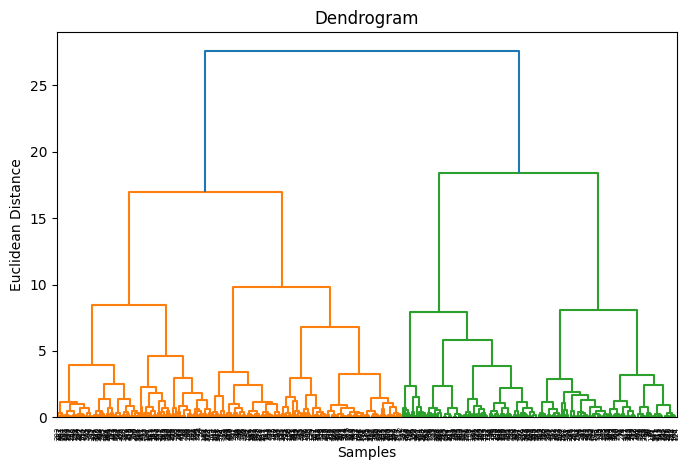

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

path = "/content/Spotify_Songs_Dataset.csv"
df = pd.read_csv(path)

df = df[['popularity', 'danceability']].dropna()

df = df.sample(n=500, random_state=42)   # IMPORTANT

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

plt.figure(figsize=(8, 5))
dendrogram(linkage(X_scaled, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [11]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
cluster = hc.fit_predict(X_scaled)

In [12]:
df['Cluster'] = cluster
print(df.head())

       popularity  danceability  Cluster
17325        45.0         0.582        0
10752        11.0         0.550        1
4561         46.0         0.412        3
16721         3.0         0.300        2
101          50.0         0.794        0


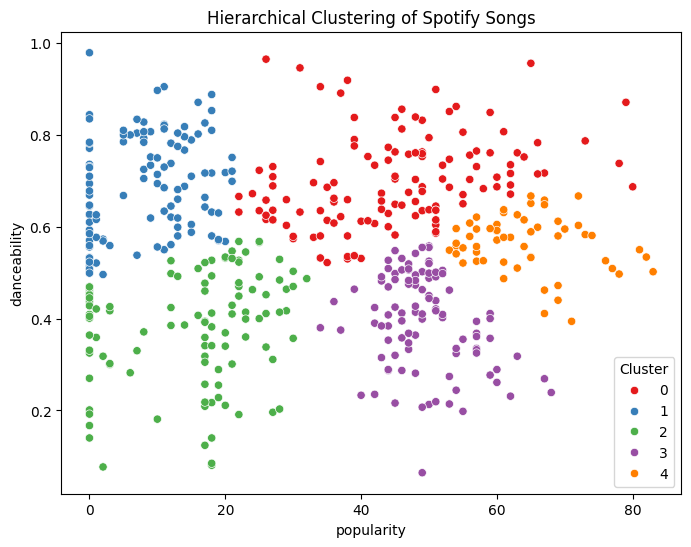

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='popularity',
                y='danceability',
                hue='Cluster',
                data=df,
                palette='Set1'
)

plt.title("Hierarchical Clustering of Spotify Songs")
plt.show()